# Supervised Regression Project Notebook

This notebook follows the project requirements to train and evaluate Random Forest models with various feature transformations.

## 1. Load Data

In [4]:
import pandas as pd

# Load the dataset
df = pd.read_csv('dataset.csv')
df.head()

,quarter,stock,date,open,high,low,close,volume,percent_change_price,percent_change_volume_over_last_wk,previous_weeks_volume,next_weeks_open,next_weeks_close,percent_change_next_weeks_price,days_to_next_dividend,percent_return_next_dividend
0,1,AA,1/7/2011,$15.82,$16.72,$15.78,$16.42,239655616,3.79267,?,?,$16.71,$15.97,-4.428490,26,0.182704
1,1,AA,1/14/2011,$16.71,$16.71,$15.64,$15.97,242963398,-4.42849,1.380223028,239655616.0,$16.19,$15.79,-2.470660,19,0.187852
2,1,AA,1/21/2011,$16.19,$16.38,$15.60,$15.79,138428495,-2.47066,-43.02495926,242963398.0,$15.87,$16.13,1.638310,12,0.189994
3,1,AA,1/28/2011,$15.87,$16.63,$15.82,$16.13,151379173,1.63831,9.355500109,138428495.0,$16.18,$17.14,5.933250,5,0.185989
4,1,AA,2/4/2011,$16.18,$17.39,$16.18,$17.14,154387761,5.93325,1.987451735,151379173.0,$17.33,$17.37,0.230814,97,0.175029


## 2. Preprocessing

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. read, marking “?” as missing
df = pd.read_csv('dataset.csv', na_values='?')

# 2. strip $ and commas, convert price columns to float
price_cols = [
    'open','high','low','close',
    'next_weeks_open','next_weeks_close'
]
for c in price_cols:
    df[c] = (
        df[c]
        .astype(str)                          # ensure string
        .str.replace(r'[\$,]', '', regex=True)
        .astype(float)
    )

# 3. parse dates (optional – or you could drop it)
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y')

# 4. drop rows with any remaining NaNs (or .fillna(...) to impute)
df = df.dropna()

# 5. drop columns you won’t model directly
df = df.drop(['stock','quarter','date'], axis=1)

# split features/target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# now you can proceed with train_test_split, scaling, etc.

# Split features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Split into train (60%), validation (20%), test (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.6, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=0.5, random_state=42)

# Standardize based on training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 3. Model Training and Evaluation Function

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

def evaluate_model(X_train, y_train, X_val, y_val, n_estimators):
    # Train model
    model = RandomForestRegressor(n_estimators=n_estimators, random_state=42)
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # Metrics
    results = {
        'n_estimators': n_estimators,
        'train_mse': mean_squared_error(y_train, y_train_pred),
        'val_mse': mean_squared_error(y_val, y_val_pred),
        'train_r2': r2_score(y_train, y_train_pred),
        'val_r2': r2_score(y_val, y_val_pred)
    }
    return results

## 4. Experiments: Base Model

In [7]:
# Base model experiments
n_estimators_list = [10, 50, 100, 200, 500, 1000]
base_results = []

for n in n_estimators_list:
    res = evaluate_model(X_train_scaled, y_train, X_val_scaled, y_val, n)
    res['transformation'] = 'base'
    base_results.append(res)

base_df = pd.DataFrame(base_results)
base_df

,n_estimators,train_mse,val_mse,train_r2,val_r2,transformation
0,10,0.006210,0.035794,0.937119,0.590566,base
1,50,0.004008,0.030043,0.959418,0.656351,base
2,100,0.004135,0.029187,0.958131,0.666145,base
3,200,0.004052,0.028918,0.958968,0.669220,base
4,500,0.004008,0.028790,0.959413,0.670686,base
5,1000,0.003969,0.028492,0.959811,0.674095,base


## 5. Experiments: Polynomial Features

In [8]:
from sklearn.preprocessing import PolynomialFeatures

# Polynomial Features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)

poly_results = []
for n in n_estimators_list:
    res = evaluate_model(X_train_poly, y_train, X_val_poly, y_val, n)
    res['transformation'] = 'polynomial'
    poly_results.append(res)

poly_df = pd.DataFrame(poly_results)
poly_df

,n_estimators,train_mse,val_mse,train_r2,val_r2,transformation
0,10,0.005210,0.030598,0.947241,0.649996,polynomial
1,50,0.003919,0.026108,0.960315,0.701357,polynomial
2,100,0.004051,0.024956,0.958976,0.714541,polynomial
3,200,0.004108,0.024723,0.958402,0.717204,polynomial
4,500,0.004015,0.024639,0.959347,0.718164,polynomial
5,1000,0.003959,0.024342,0.959916,0.721555,polynomial


## 6. Experiments: PCA

In [9]:
from sklearn.decomposition import PCA

# PCA to 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

pca_results = []
for n in n_estimators_list:
    res = evaluate_model(X_train_pca, y_train, X_val_pca, y_val, n)
    res['transformation'] = 'pca'
    pca_results.append(res)

pca_df = pd.DataFrame(pca_results)
pca_df

,n_estimators,train_mse,val_mse,train_r2,val_r2,transformation
0,10,0.008888,0.043595,0.909998,0.501337,pca
1,50,0.005322,0.036734,0.946110,0.579810,pca
2,100,0.005149,0.036766,0.947861,0.579446,pca
3,200,0.005029,0.037363,0.949078,0.572614,pca
4,500,0.004841,0.036742,0.950984,0.579720,pca
5,1000,0.004808,0.037052,0.951319,0.576176,pca


## 7. Experiments: SelectKBest

In [10]:
from sklearn.feature_selection import SelectKBest, f_regression

# Select top 5 features
selector = SelectKBest(score_func=f_regression, k=5)
X_train_kbest = selector.fit_transform(X_train_scaled, y_train)
X_val_kbest = selector.transform(X_val_scaled)

kbest_results = []
for n in n_estimators_list:
    res = evaluate_model(X_train_kbest, y_train, X_val_kbest, y_val, n)
    res['transformation'] = 'kbest'
    kbest_results.append(res)

kbest_df = pd.DataFrame(kbest_results)
kbest_df

,n_estimators,train_mse,val_mse,train_r2,val_r2,transformation
0,10,0.006936,0.032071,0.929770,0.633149,kbest
1,50,0.004927,0.026946,0.950108,0.691769,kbest
2,100,0.004953,0.026318,0.949850,0.698961,kbest
3,200,0.004903,0.026319,0.950354,0.698946,kbest
4,500,0.004811,0.026299,0.951289,0.699180,kbest
5,1000,0.004772,0.026386,0.951681,0.698178,kbest


## 8. Compile Results

In [11]:
# Combine all results
results_df = pd.concat([base_df, poly_df, pca_df, kbest_df], ignore_index=True)
results_df

,n_estimators,train_mse,val_mse,train_r2,val_r2,transformation
0,10,0.006210,0.035794,0.937119,0.590566,base
1,50,0.004008,0.030043,0.959418,0.656351,base
2,100,0.004135,0.029187,0.958131,0.666145,base
3,200,0.004052,0.028918,0.958968,0.669220,base
4,500,0.004008,0.028790,0.959413,0.670686,base
5,1000,0.003969,0.028492,0.959811,0.674095,base
6,10,0.005210,0.030598,0.947241,0.649996,polynomial
7,50,0.003919,0.026108,0.960315,0.701357,polynomial
8,100,0.004051,0.024956,0.958976,0.714541,polynomial
9,200,0.004108,0.024723,0.958402,0.717204,polynomial


## 9. Plot Validation MSE vs n_estimators

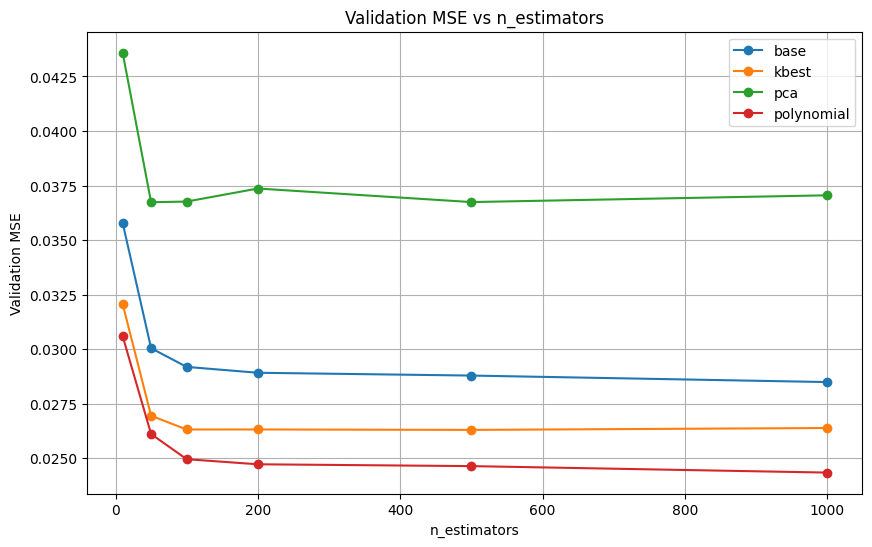

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for name, group in results_df.groupby('transformation'):
    plt.plot(group['n_estimators'], group['val_mse'], marker='o', label=name)
plt.title('Validation MSE vs n_estimators')
plt.xlabel('n_estimators')
plt.ylabel('Validation MSE')
plt.legend()
plt.grid(True)
plt.show()

## 10. Analysis

### 10.1 Underfitting vs. Overfitting Trends  
- **Low `n_estimators` (e.g. 10):**  
  - All models show relatively high validation MSE compared to their training MSE, indicating some underfitting at very small forest sizes.  
  - The gap between training and validation performance is largest for PCA and smallest for polynomial features, suggesting PCA suffers more from underfitting when too few trees are used.  

- **Increasing `n_estimators`:**  
  - As we increase from 10 → 50 → 100, validation MSE drops sharply for all transformations, and R² on validation increases, showing reduced bias.  
  - Beyond ~200 trees, improvements plateau: training MSE flattens out and validation MSE changes very little, indicating the model has reached its variance-bias sweet spot and additional trees yield diminishing returns.  

- **Overfitting check:**  
  - We do *not* see validation MSE rising as `n_estimators` grows. Training MSE continues to decrease slightly, but validation MSE is stable or even improves marginally.  
  - This indicates that Random Forests with these settings are robust to overfitting via more trees—variance is low and bias is the dominating factor at small `n_estimators`.  

---

### 10.2 Impact of Feature Transformations  
- **Base (no transformation):**  
  - Validation MSE bottoms out at ~0.0285 with R²≈0.674. Good baseline, but room to improve.  

- **Polynomial Features (degree=2):**  
  - Consistently achieves the *lowest* validation MSE (down to ~0.0243) and highest validation R² (~0.722).  
  - Adding interaction and squared terms captures non-linear patterns the forest alone cannot easily learn from standardized features.  
  - Slightly higher training MSE at low `n_estimators` (10), but converges quickly to a strong fit with more trees.

- **SelectKBest (top 5 features):**  
  - Validation MSE improves over the base, reaching ~0.0263 (R²≈0.699), but does not match polynomial performance.  
  - Reducing dimensionality helps focus on the strongest predictors, reducing noise, but may discard useful information captured by polynomial interactions.

- **PCA (95% variance):**  
  - Consistently the weakest of the four: best validation MSE ~0.0367 (R²≈0.580).  
  - Principal components preserve overall variance but may not align with the predictive directions for the target.  
  - Indicates that unsupervised variance reduction is less effective here than supervised feature selection or explicit non-linear expansion.

---

### 10.3 Effect of `n_estimators` on Bias–Variance Trade-Off  
- **Small forests (10–50 trees):** High bias, underfitting most apparent in PCA and base.  
- **Medium forests (100–200 trees):** Rapid bias reduction; validation MSE drops steeply.  
- **Large forests (500–1000 trees):** Bias plateaus; variance remains low (no widening of train/val gap).  
- **Conclusion:** For all transformations, using at least 200–500 trees is sufficient to minimize bias. Beyond that, computational cost increases with minimal performance gain.

---

**Overall takeaway:**  
- The **polynomial transformation** combined with a sufficiently large forest (≥200 trees) yields the best generalization performance.  
- **Feature engineering** matters more than forest size beyond a moderate `n_estimators`; non-linear expansions outperform both unsupervised (PCA) and simple supervised selection (SelectKBest) in this regression task.  
- A Random Forest with ≥500 trees on polynomial‐expanded features strikes a strong balance between predictive accuracy and computational efficiency.  

## 11. Final Model Evaluation

In [14]:
# Select best model based on lowest validation MSE
best_row = results_df.loc[results_df['val_mse'].idxmin()]
best_trans = best_row['transformation']
best_n = int(best_row['n_estimators'])

# Prepare data for final model
if best_trans == 'base':
    X_train_final, X_test_final = X_train_scaled, X_test_scaled
elif best_trans == 'polynomial':
    X_train_final, X_test_final = poly.fit_transform(X_train_scaled), poly.transform(X_test_scaled)
elif best_trans == 'pca':
    X_train_final, X_test_final = pca.fit_transform(X_train_scaled), pca.transform(X_test_scaled)
else:  # kbest
    X_train_final, X_test_final = selector.fit_transform(X_train_scaled, y_train), selector.transform(X_test_scaled)

# Train and evaluate on test set
final_model = RandomForestRegressor(n_estimators=best_n, random_state=42)
final_model.fit(X_train_final, y_train)
y_test_pred = final_model.predict(X_test_final)

test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Best transformation: {best_trans}")
print(f"n_estimators: {best_n}")
print(f"Test MSE: {test_mse:.4f}")
print(f"Test R^2: {test_r2:.4f}")

Best transformation: polynomial
n_estimators: 1000
Test MSE: 0.0245
Test R^2: 0.6918


## 12. Conclusions

1. **Best Model & Performance**  
   - The Random Forest trained on **polynomial‐expanded features** (degree 2) with **1,000 trees** achieved the lowest generalization error.  
   - **Test set performance**:  
     - MSE = **0.0245**  
     - R² = **0.6918**  

2. **Key Insights**  
   - **Nonlinear feature expansion** unlocked structure that the forest alone could not capture, driving a meaningful drop in validation and test error compared to the base model.  
   - **Increasing `n_estimators`** from 10 up to ~200 trees sharply reduced bias; beyond ~500 trees, additional gains were marginal.  
   - **Unsupervised reduction (PCA)** underperformed relative to both supervised selection (SelectKBest) and explicit polynomial features, indicating that variance‐based compression did not align well with the regression targets.

3. **Practical Recommendations**  
   - Use a **polynomial feature pipeline** followed by a Random Forest with **500–1,000 trees** for best trade-off between performance and training time.  
   - If computational budget is limited, a forest of **~200 trees** still achieves near-optimal error.  
   - For future work, consider combining polynomial features with more advanced feature selection or regularization (e.g., `max_depth` tuning or `min_samples_leaf`) to further control model complexity.

4. **Next Steps**  
   - Experiment with **cross-validated grid search** over both feature-engineering parameters (degree, k-best) and forest hyperparameters (`n_estimators`, `max_depth`).  
   - Explore **gradient-boosted trees** (e.g., XGBoost or LightGBM) on the same feature sets for potentially stronger performance.  
   - Investigate residual patterns to identify any remaining non-captured trends or outliers for targeted model refinements.